### Reproduce https://github.com/jjcherian/conditional-conformal/blob/release/experiments/SyntheticData.ipynb with a minimal manual implem

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from tqdm import tqdm

from scipy.optimize import linprog


In [2]:
def generate_cqr_data(seed,n_train=2000,n_calib=1000,n_test=500):
    np.random.seed(seed)

    n_train = n_train + n_calib
    
    def f(x):
        ''' Construct data (1D example)
        '''
        ax = 0*x
        for i in range(len(x)):
            ax[i] = (np.random.poisson(np.sin(x[i])**2+0.1) + 0.03*x[i]*np.random.randn(1)).item()
            ax[i] += (25*(np.random.uniform(0,1,1)<0.01)*np.random.randn(1)).item()
        return ax.astype(np.float32)

    # training features
    x_train = np.random.uniform(0, 5.0, size=n_train).astype(np.float32)

    # test features
    x_test = np.random.uniform(0, 5.0, size=n_test).astype(np.float32)

    # generate labels
    y_train = f(x_train)
    y_test = f(x_test)

    # reshape the features
    x_train = np.reshape(x_train,(n_train,1))
    x_test = np.reshape(x_test,(n_test,1))
    
    train_set_size = len(y_train) - n_calib
    x_train_final = x_train[ : train_set_size]
    x_calib = x_train[train_set_size : ]
    y_train_final = y_train[ : train_set_size]
    y_calib = y_train[train_set_size : ]
    
    return x_train_final, y_train_final, x_calib, y_calib, x_test, y_test


def indicator_matrix(scalar_values, disc):
    scalar_values = np.array(scalar_values)

    # Create all possible intervals
    intervals = [(disc[i], disc[i + 1]) for i in range(len(disc) - 1)]

    # Initialize the indicator matrix
    matrix = np.zeros((len(scalar_values), len(intervals)))

    # Fill in the indicator matrix
    for i, value in enumerate(scalar_values):
        for j, (a, b) in enumerate(intervals):
            if a <= value < b:
                matrix[i, j] = 1

    return matrix

In [3]:
# generate data
x_train_final, y_train_final, x_calib, y_calib, x_test, y_test = generate_cqr_data(seed=1, n_calib=2000)

# fit a fourth order polynomial
# NB: the polynomial features are embedded in a Pipeline so that the estimator
# can be called directly on the raw covariates `x` (1 column). This is required
# by MAPIE, which internally calls `reg.predict(X)` on the raw features, while
# the conditional basis `phi_fn` is also defined on the raw `x`.
reg = make_pipeline(PolynomialFeatures(4), LinearRegression()).fit(x_train_final, y_train_final)

# nominal level is 0.9
alpha = 0.1

# score function is residual
score_fn = lambda x, y : y - reg.predict(x)
score_inv_fn_ub = lambda s, x : [-np.inf, reg.predict(x) + s]
score_inv_fn_lb = lambda s, x : [reg.predict(x) + s, np.inf]

# coverage on indicators of all sub-intervals with endpoints in [0,0.5,1,..,5]
eps = 0.5
disc = np.arange(0, 5 + eps, eps)

def phi_fn_groups(x):
    return indicator_matrix(x, disc)

# coverage on Gaussians with mu=loc and sd=scale 
# scale = 1 for x != [1.5, 3.5]
eval_locs = [1.5, 3.5]
eval_scale = 0.2

other_locs = [0.5, 2.5, 4.5]
other_scale = 1

def phi_fn_shifts(x):
    shifts = [norm.pdf(x, loc=loc, scale=eval_scale).reshape(-1,1)
                   for loc in eval_locs]
    shifts.extend([norm.pdf(x, loc=loc, scale=other_scale).reshape(-1,1)
                   for loc in other_locs])
    shifts.append(np.ones((x.shape[0], 1)))
    return np.concatenate(shifts, axis=1)

# intercept only phi_fn
def phi_fn_intercept(x):
    return np.ones((x.shape[0], 1))

In [4]:
experiment = 'groups' # valid choices: ['groups', 'shifts', 'agnostic']

In [5]:
if experiment == 'groups':
    phi_fn = phi_fn_groups
    infinite_params = {}
elif experiment == 'shifts':
    phi_fn = phi_fn_shifts
    infinite_params = {}
elif experiment == 'agnostic':
    phi_fn = phi_fn_intercept
    infinite_params = {'kernel': 'rbf', 'gamma': 12.5, 'lambda': 0.005}
else:
    raise ValueError(f"Invalid value for experiment: {experiment}.")

## tests implementation MAPIE

In [6]:
from mapie.conformity_scores import AbsoluteConformityScore

x_calib = np.asarray(x_calib, dtype=np.float64)
y_calib = np.asarray(y_calib, dtype=np.float64)

from mapie.conditional_conformal_prediction import ConditionalSplitConformalRegressor
mapie_conditional = ConditionalSplitConformalRegressor(
    phi_fn,
    estimator=reg,
    prefit=True,
    conformity_score=AbsoluteConformityScore(sym=False),
)
mapie_conditional.conformalize(x_calib, y_calib)

_, intervals = mapie_conditional.predict_interval(x_test)
lbs = intervals[:, 0, 0]
ubs = intervals[:, 1, 0]

# Plot predictions

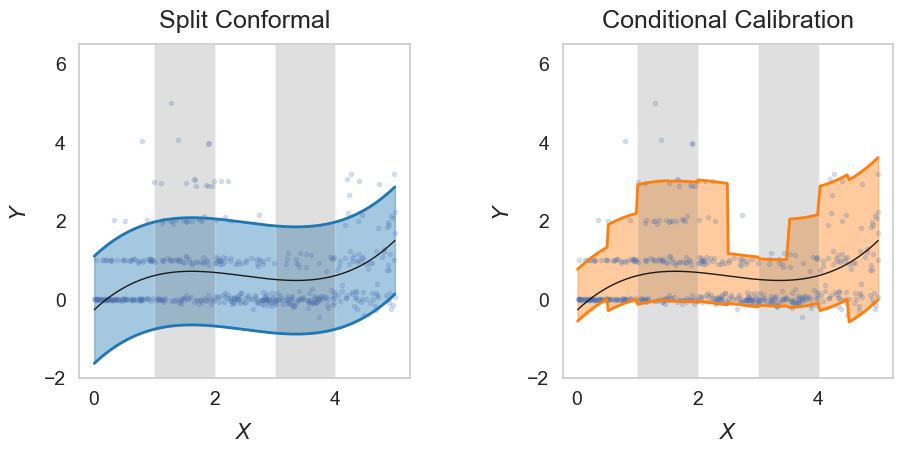

In [7]:
q = np.quantile(np.abs(reg.predict(x_calib) - y_calib),
                np.ceil((len(x_calib) + 1) * (0.9)) / len(x_calib),)

cp = sns.color_palette()
sns.set(font="DejaVu Sans")
sns.set_style("whitegrid", {'axes.grid' : False})
fig = plt.figure()
fig.set_size_inches(10.5, 6)

sort_order = np.argsort(x_test[:,0])
x_test_s = x_test[sort_order]
y_test_s = y_test[sort_order]
y_test_hat = reg.predict(x_test[sort_order])
lb = lbs[sort_order]
ub = ubs[sort_order]


ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(x_test_s, y_test_s, '.', alpha=0.2)
ax1.plot(x_test_s, y_test_hat, lw=1, color='k')
ax1.plot(x_test_s, y_test_hat + q, color=cp[0], lw=2)
ax1.plot(x_test_s, y_test_hat - q, color=cp[0], lw=2)
ax1.fill_between(x_test_s.flatten(), y_test_hat - q, y_test_hat + q, 
                 color=cp[0], alpha=0.4, label='split prediction interval')
ax1.set_ylim(-2,6.5)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.set_xlabel("$X$", fontsize=16, labelpad=10)
ax1.set_ylabel("$Y$", fontsize=16, labelpad=10)
ax1.set_title("Split Conformal", fontsize=18, pad=12)

if experiment == 'groups':
    ax1.axvspan(1, 2, facecolor='grey', alpha=0.25)
    ax1.axvspan(3, 4, facecolor='grey', alpha=0.25)
else:
    for loc in eval_locs:
        ax1.plot(x_test_s, norm.pdf(x_test_s, loc=loc, scale=eval_scale), color='grey', ls='--', lw=3)

ax2 = fig.add_subplot(1, 2, 2, sharex = ax1, sharey = ax1)
ax2.plot(x_test_s, y_test_s, '.', alpha=0.2)
ax2.plot(x_test_s, y_test_hat, color='k', lw=1)
ax2.plot(x_test_s, ub, color=cp[1], lw=2)
ax2.plot(x_test_s, lb, color=cp[1], lw=2)
ax2.fill_between(x_test_s.flatten(), lb, 
                 ub, 
                 color=cp[1], alpha=0.4, label='conditional calibration')

ax2.tick_params(axis='both', which='major', direction='out', labelsize=14)
ax2.set_xlabel("$X$", fontsize=16, labelpad=10)
ax2.set_ylabel("$Y$", fontsize=16, labelpad=10)
ax2.set_title("Conditional Calibration", fontsize=18, pad=12)

if experiment == 'groups':
    ax2.axvspan(1, 2, facecolor='grey', alpha=0.25)
    ax2.axvspan(3, 4, facecolor='grey', alpha=0.25)
else:
    for loc in eval_locs:
        ax2.plot(x_test_s, norm.pdf(x_test_s, loc=loc, scale=eval_scale), color='grey', ls='--', lw=3)

plt.tight_layout(pad=5)

